Read data from .root file

In [44]:
import uproot 
import hist
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Open the ROOT file and read the TTree
with uproot.open("./Outputs/L1PCA_11Li.root") as file:
    tree = file["L1PCA"].arrays(library="pd")





In [45]:
tree.describe()

,fQave,fLight_fQtotal,fThetaLight,fLight_fTL,fPhiLight
count,366976.000000,366976.000000,366976.000000,366976.000000,366976.000000
mean,1064.636475,66505.250000,68.442696,91.449448,6.024891
std,517.970398,43570.050781,20.881296,54.249847,97.871025
min,27.156414,677.125061,1.719536,1.184015,-180.000000
25%,829.522888,40439.244141,54.896950,48.435782,-82.972794
50%,1089.392151,59821.052734,78.353798,76.195255,25.665118
75%,1349.431458,84579.339844,81.111290,122.388931,93.092094
max,6918.620605,975811.437500,179.703918,330.673370,180.000000


In [46]:
#Add sin and cosin of phi and theta
tree["fSinPhi"]=np.sin(tree["fPhiLight"])
tree["fCosPhi"]=np.cos(tree["fPhiLight"])
tree["fSinTheta"]=np.sin(tree["fThetaLight"])
tree["fCosTheta"]=np.cos(tree["fThetaLight"])

In [55]:
#Add Charge / cosTheta
tree["fChargeOverCosTheta"]=tree["fLight_fQtotal"]/np.cos(tree["fThetaLight"])

DO THE PCA

In [56]:

# select numeric columns only
num_cols = tree.select_dtypes(include=["number"]).columns
# compute population standard deviation (ddof=0) and avoid zeros
stds = tree[num_cols].std(ddof=0)
stds = stds.replace(0, 1.0)
# create normalized copy
df_norm = tree.copy()
df_norm[num_cols] = tree[num_cols] / stds
print('Normalized numeric columns by std (ddof=0):')
print(stds)
# inspect first rows
print(df_norm.head())

Normalized numeric columns by std (ddof=0):
fQave                  5.179697e+02
fLight_fQtotal         4.356999e+04
fThetaLight            2.088127e+01
fLight_fTL             5.424977e+01
fPhiLight              9.787089e+01
fSinPhi                7.064511e-01
fCosPhi                7.077609e-01
fSinTheta              7.037758e-01
fCosTheta              7.078328e-01
fChargeOverCosTheta    3.561548e+07
dtype: float32
      fQave  fLight_fQtotal  fThetaLight  fLight_fTL  fPhiLight   fSinPhi  \
0  2.087802        1.668582     3.813254    1.390244   0.388849  0.495904   
1  0.138293        0.114217     1.744299    2.610427  -0.614196  0.579314   
2  2.903811        0.870221     3.396155    0.598092   1.075275 -1.415507   
3  2.423199        2.117818     2.454247    1.562899  -1.338842  1.120390   
4  1.991984        1.356142     3.867431    1.246130   0.356922 -0.518110   

    fCosPhi  fSinTheta  fCosTheta  fChargeOverCosTheta  
0  1.323364  -1.257014  -0.658692            -0.004378  
1 -1

In [57]:
pca=PCA(n_components=3)
pca.fit(df_norm[num_cols])
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Principal components:\n', pca.components_)


Explained variance ratio: [0.20971355 0.1208461  0.10094205]
Principal components:
 [[-5.6449473e-01  8.2287580e-02 -5.0108969e-01  6.3400912e-01
  -8.1078887e-02  8.2047604e-04  5.1347855e-03  5.0882045e-02
  -1.1101255e-01  1.5535384e-03]
 [ 3.9717868e-01  8.5112810e-01 -4.4484694e-02  1.4368796e-01
  -1.0536335e-01 -7.8928322e-03  1.9946171e-02  9.6768083e-04
  -2.8914812e-01 -5.9790690e-03]
 [ 7.5146928e-02  7.7844448e-02 -9.5879219e-02  1.3391458e-02
   4.9018046e-01 -2.4849640e-01 -8.8430680e-02  7.8901136e-01
   1.8090469e-01 -1.1750869e-01]]


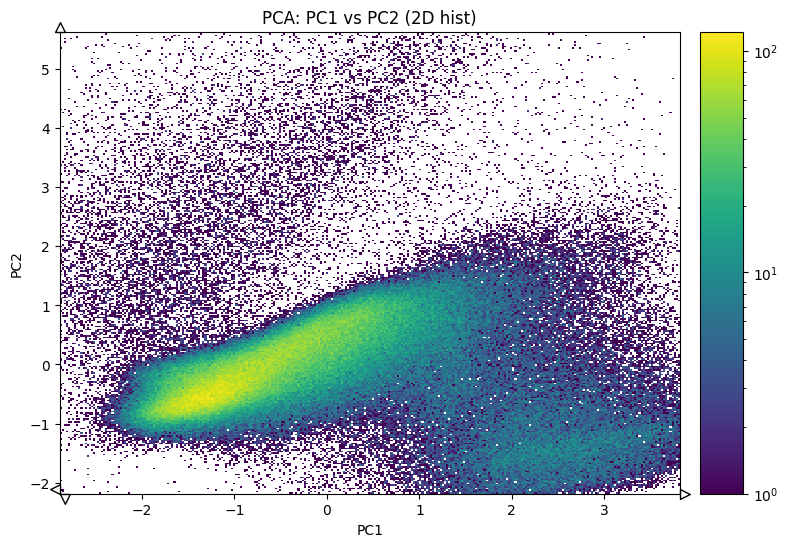

In [58]:
# 2D histogram of the first two PCA components using `hist`
pca_result = pca.transform(df_norm[num_cols])
pc1 = pca_result[:, 0]
pc2 = pca_result[:, 1]
# use robust percentile-driven ranges to avoid extreme outliers
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])
# build a 2D hist with the `hist` package
h2 = hist.Hist(hist.axis.Regular(300, xmin, xmax, name="PC1"),
               hist.axis.Regular(300, ymin, ymax, name="PC2"))
h2.fill(PC1=pc1, PC2=pc2)
# draw with matplotlib (use pcolormesh from the histogram edges and values)
fig, ax = plt.subplots(figsize=(8,6))
h2.plot(ax=ax,norm=mcolors.LogNorm(), cmap='viridis')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 (2D hist)')
plt.show()